Import Libraries

In [8]:
import warnings
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import kerastuner as kt

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow version :', tf.__version__)
print('Keras Tuner version:', kt.__version__)

TensorFlow version : 2.19.0
Keras Tuner version: 1.0.5


Load and Analyse Data

In [9]:
df = pd.read_csv('/content/student-scores (1).csv')
df.head()

,id,first_name,last_name,email,gender,part_time_job,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,False,10,Unknown,84,77,65,65,80,74,76


In [10]:
print('Shape:', df.shape)

Shape: (2000, 16)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   extracurricular_activities  2000 non-null   bool  
 7   weekly_self_study_hours     2000 non-null   int64 
 8   career_aspiration           2000 non-null   object
 9   math_score                  2000 non-null   int64 
 10  history_score               2000 non-null   int64 
 11  physics_score               2000 non-null   int64 
 12  chemistry_score             2000 non-null   int64 
 13  biology_score               2000 non-null   int6

In [12]:
print('Missing values:\n', df.isnull().sum())

Missing values:
 id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64


In [13]:
print('\nTarget distribution:')
print(df['career_aspiration'].value_counts())


Target distribution:
career_aspiration
Software Engineer        315
Business Owner           309
Unknown                  223
Banker                   169
Lawyer                   138
Accountant               126
Doctor                   119
Real Estate Developer     83
Stock Investor            73
Construction Engineer     68
Artist                    67
Game Developer            63
Government Officer        61
Teacher                   59
Designer                  56
Scientist                 39
Writer                    32
Name: count, dtype: int64


Data Modification

In [14]:
df['career_aspiration'] = df['career_aspiration'].replace('Unknown', 'Any Suitable Career')
print(df['career_aspiration'].value_counts())

career_aspiration
Software Engineer        315
Business Owner           309
Any Suitable Career      223
Banker                   169
Lawyer                   138
Accountant               126
Doctor                   119
Real Estate Developer     83
Stock Investor            73
Construction Engineer     68
Artist                    67
Game Developer            63
Government Officer        61
Teacher                   59
Designer                  56
Scientist                 39
Writer                    32
Name: count, dtype: int64


Preprocessing

In [15]:
df.drop(columns=['id', 'first_name', 'last_name', 'email'], inplace=True)
df.head()

,gender,part_time_job,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,male,False,False,27,Lawyer,73,81,93,97,63,80,87
1,female,False,False,47,Doctor,90,86,96,100,90,88,90
2,female,False,True,13,Government Officer,81,97,95,96,65,77,94
3,female,False,False,3,Artist,71,74,88,80,89,63,86
4,male,False,False,10,Any Suitable Career,84,77,65,65,80,74,76


In [16]:
#Boolean Encoding
for col in ['part_time_job', 'extracurricular_activities']:
    if df[col].dtype == object:
        df[col] = df[col].str.strip().str.upper().map({'TRUE': 1, 'FALSE': 0})
    else:
        df[col] = df[col].astype(int)

#Gender Encoding
df['gender'] = LabelEncoder().fit_transform(df['gender'])

#Gender Encoding
label_enc = LabelEncoder()
df['career_aspiration'] = label_enc.fit_transform(df['career_aspiration'])
num_classes = len(label_enc.classes_)

df.head()

,gender,part_time_job,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,0,0,27,10,73,81,93,97,63,80,87
1,0,0,0,47,7,90,86,96,100,90,88,90
2,0,0,1,13,9,81,97,95,96,65,77,94
3,0,0,0,3,2,71,74,88,80,89,63,86
4,1,0,0,10,1,84,77,65,65,80,74,76


In [17]:
X = df.drop(columns=['career_aspiration'])
y = df['career_aspiration']

Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
X_train

,gender,part_time_job,extracurricular_activities,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
968,0,0,1,6,97,78,99,88,69,98,60
240,1,0,0,27,91,81,91,76,100,92,87
819,1,1,1,2,46,71,60,50,85,69,62
692,1,1,0,1,57,75,64,85,53,95,81
420,0,0,0,14,69,69,84,100,69,77,87
...,...,...,...,...,...,...,...,...,...,...,...
1130,1,0,0,11,88,98,81,61,62,96,60
1294,0,0,0,34,84,74,90,99,90,92,72
860,1,0,0,25,100,62,78,74,72,73,78
1459,0,1,1,10,71,70,87,62,92,63,80


In [20]:
y_train

,career_aspiration
968,1
240,13
819,4
692,4
420,15
...,...
1130,3
1294,3
860,13
1459,6


In [21]:
X_test

,gender,part_time_job,extracurricular_activities,weekly_self_study_hours,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
1860,1,0,0,19,97,95,91,97,96,90,67
353,1,0,0,1,85,64,90,94,68,97,61
1333,0,0,0,16,80,62,66,88,75,98,68
905,1,0,0,5,57,74,98,93,63,70,67
1289,1,0,0,2,86,93,91,64,69,71,64
...,...,...,...,...,...,...,...,...,...,...,...
965,0,0,0,14,94,82,80,80,33,93,78
1284,0,0,0,15,92,65,88,78,67,95,96
1739,1,0,0,35,88,92,88,100,89,94,87
261,1,0,0,2,76,93,65,95,76,88,88


In [22]:
y_test

,career_aspiration
1860,3
353,8
1333,15
905,11
1289,8
...,...
965,0
1284,3
1739,13
261,2


Scaling

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [24]:
X_train

array([[-0.99252792, -0.43440451,  1.93228564, ..., -0.77943534,
         1.40593301, -1.80405955],
       [ 1.00752834, -0.43440451, -0.51752183, ...,  1.51410956,
         0.90398214,  0.53599067],
       [ 1.00752834,  2.30200187,  1.93228564, ...,  0.40432977,
        -1.02016285, -1.63072249],
       ...,
       [ 1.00752834, -0.43440451, -0.51752183, ..., -0.55747938,
        -0.68552894, -0.24402607],
       [-0.99252792,  2.30200187,  1.93228564, ...,  0.92222701,
        -1.52211372, -0.07068902],
       [ 1.00752834, -0.43440451, -0.51752183, ...,  0.10838849,
         1.32227453, -1.02404281]])

In [25]:
X_test

array([[ 1.00752834, -0.43440451, -0.51752183, ...,  1.21816829,
         0.73666518, -1.19737986],
       [ 1.00752834, -0.43440451, -0.51752183, ..., -0.85342066,
         1.32227453, -1.71739102],
       [-0.99252792, -0.43440451, -0.51752183, ..., -0.33552342,
         1.40593301, -1.11071133],
       ...,
       [ 1.00752834, -0.43440451, -0.51752183, ...,  0.70027105,
         1.07129909,  0.53599067],
       [ 1.00752834, -0.43440451, -0.51752183, ..., -0.2615381 ,
         0.56934823,  0.62265919],
       [ 1.00752834, -0.43440451, -0.51752183, ..., -1.07537662,
        -0.26723655,  0.18931656]])

Correlation

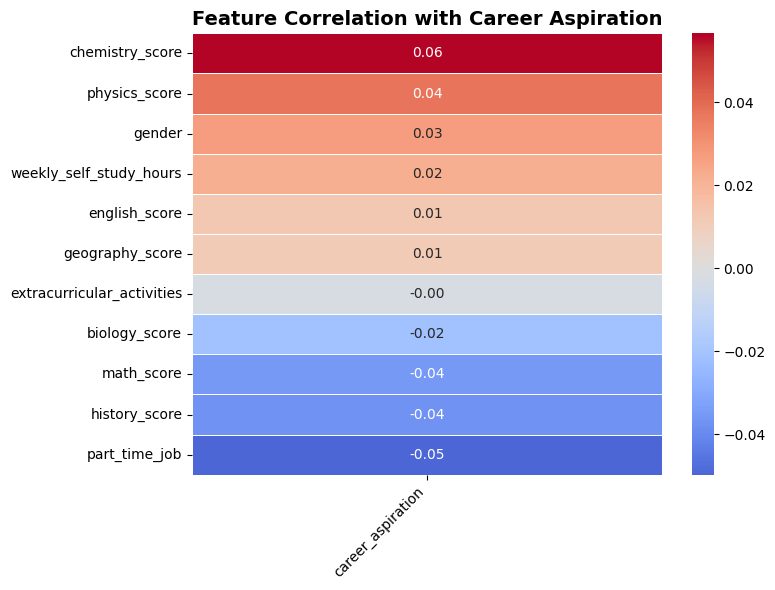

In [26]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_train_df['career_aspiration'] = y_train

target_corr = X_train_df.corr()[['career_aspiration']].drop('career_aspiration')
target_corr = target_corr.sort_values('career_aspiration', ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(
    target_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Feature Correlation with Career Aspiration', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Model Build with Keras Tuner

In [27]:
def build_model(hp):

    model = keras.Sequential()
    model.add(layers.InputLayer(shape=(X_train.shape[1],)))

    num_layers = hp.Int('num_layers', min_value=1, max_value=4, step=1)

    unit_options = [
        [128, 256, 512],
        [64, 128, 256],
        [32, 64, 128],
        [16, 32, 64],
    ]

    for i in range(num_layers):
        units        = hp.Choice(f'units_{i}',       values=unit_options[i])
        activation   = hp.Choice(f'activation_{i}',  values=['relu', 'tanh', 'elu'])
        initializer  = hp.Choice(f'initializer_{i}', values=['he_uniform', 'glorot_uniform',
                                                              'he_normal',  'glorot_normal'])
        l2_reg       = hp.Choice(f'l2_{i}', values=[0.0, 0.001, 0.0001])
        use_bn       = hp.Boolean(f'batch_norm_{i}')
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)

        model.add(layers.Dense(units, activation=activation,
                               kernel_initializer=initializer,
                               kernel_regularizer=keras.regularizers.l2(l2_reg)))
        if use_bn:
            model.add(layers.BatchNormalization())
        if dropout_rate > 0.0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(num_classes, activation='softmax'))

    lr             = hp.Choice('learning_rate', values=[0.1, 0.01, 0.05, 0.001, 0.005])
    optimizer_name = hp.Choice('optimizer',     values=['adam', 'rmsprop', 'nadam'])
    use_schedule   = hp.Boolean('lr_schedule')

    if use_schedule:
        lr_schedule = keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=lr, decay_steps=100, decay_rate=0.9
        )
        lr_value = lr_schedule
    else:
        lr_value = lr

    optimizers = {
        'adam'   : keras.optimizers.Adam(learning_rate=lr_value),
        'rmsprop': keras.optimizers.RMSprop(learning_rate=lr_value),
        'nadam'  : keras.optimizers.Nadam(learning_rate=lr_value)
    }

    model.compile(
        optimizer=optimizers[optimizer_name],
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

RandomSearch

In [28]:
tuner = kt.BayesianOptimization(
    build_model,
    objective=kt.Objective('val_accuracy', direction='max'),
    max_trials=50,
    num_initial_points=10,
    executions_per_trial=2,
    directory='kt_results',
    project_name='career_aspiration_ann',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 10
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Choice)
{'default': 128, 'conditions': [], 'values': [128, 256, 512], 'ordered': True}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'elu'], 'ordered': False}
initializer_0 (Choice)
{'default': 'he_uniform', 'conditions': [], 'values': ['he_uniform', 'glorot_uniform', 'he_normal', 'glorot_normal'], 'ordered': False}
l2_0 (Choice)
{'default': 0.0, 'conditions': [], 'values': [0.0, 0.001, 0.0001], 'ordered': True}
batch_norm_0 (Boolean)
{'default': False, 'conditions': []}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.1, 'conditions': [], 'values': [0.1, 0.01, 0.05, 0.001, 0.005], 'ordered': True}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'value

OverFit Avoidence

In [29]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

Searching Best Parameters

In [30]:
tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Trial 50 Complete [00h 00m 29s]
val_accuracy: 0.4612500071525574

Best val_accuracy So Far: 0.4662500023841858
Total elapsed time: 00h 30m 44s


Best Hyperparameters & Model

In [31]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print('── Best Hyperparameters ──')
for key, val in best_hps.values.items():
    print(f'  {key}: {val}')

── Best Hyperparameters ──
  num_layers: 3
  units_0: 128
  activation_0: elu
  initializer_0: he_uniform
  l2_0: 0.0001
  batch_norm_0: False
  dropout_0: 0.0
  learning_rate: 0.005
  optimizer: adam
  lr_schedule: False
  units_1: 256
  activation_1: elu
  initializer_1: he_uniform
  l2_1: 0.0
  batch_norm_1: True
  dropout_1: 0.4
  units_2: 64
  activation_2: tanh
  initializer_2: glorot_normal
  l2_2: 0.0
  batch_norm_2: False
  dropout_2: 0.30000000000000004
  units_3: 64
  activation_3: relu
  initializer_3: he_uniform
  l2_3: 0.0
  batch_norm_3: False
  dropout_3: 0.4


In [32]:
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 17)             │         1,105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,137 (207.57 KB)

 Trainable params: 52,625 (205.57 KB)

 Non-trainable params: 512 (2.00 KB)

Final Training with Best Hyperparameters

In [33]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True
    )
]

history = best_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.2054 - loss: 2.7752 - val_accuracy: 0.3675 - val_loss: 2.1396
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3514 - loss: 2.0882 - val_accuracy: 0.4000 - val_loss: 2.0103
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3764 - loss: 1.9556 - val_accuracy: 0.4250 - val_loss: 1.9178
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4017 - loss: 1.8680 - val_accuracy: 0.4050 - val_loss: 1.8585
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3907 - loss: 1.7985 - val_accuracy: 0.4250 - val_loss: 1.8519
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4069 - loss: 1.7975 - val_accuracy: 0.4325 - val_loss: 1.8007
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4387 - loss: 1.7431 - val_accuracy: 0.4350 - val_loss: 1.7949
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4365 - loss: 1.7030 - val_accuracy: 0.4350 - 

Evaluation on Test Set

In [34]:
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

Test Loss     : 1.7193
Test Accuracy : 0.4525


Training Curves

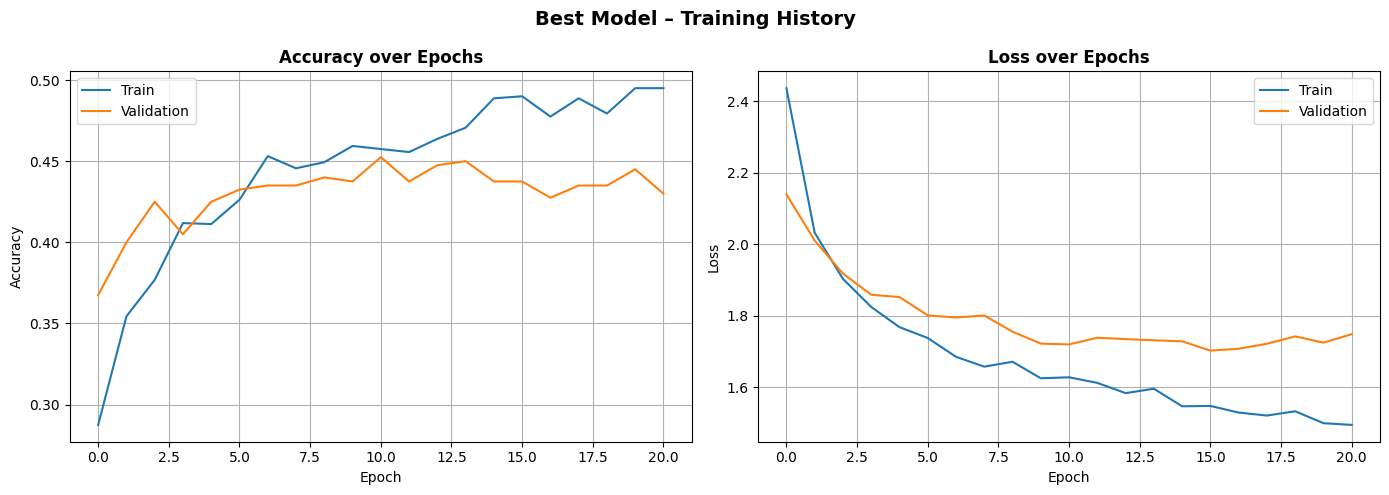

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Best Model – Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Export Model

In [37]:
# ===============================
# Save trained model and tools
# ===============================

import os

save_dir = "trained_models"
os.makedirs(save_dir, exist_ok=True)

# Save full model
best_model.save(os.path.join(save_dir, "career_model.keras"))

# Save scaler and label encoder
joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))
joblib.dump(label_enc, os.path.join(save_dir, "Label.pkl"))

print("✅ Model, scaler, and label encoder saved successfully!")

✅ Model, scaler, and label encoder saved successfully!
